In [1]:
import requests
from bs4 import BeautifulSoup
import json
import csv
import time

In [2]:

# Define headers for HTTP requests
HEADERS = {
    "User-Agent": 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/129.0.0.0 Safari/537.36',
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate, br",
    "DNT": "1",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
}

# Base URL and maximum pages
BASE_URL = "https://www.zillow.com/ne"
MAX_PAGES = 40  # Number of pages to scrape

# Output CSV file
OUTPUT_FILE = "zillow_scraped_data.csv"

# Data storage
scraped_data = []

# Function to save data to CSV
def save_to_csv(data, output_file):
    if not data:
        print("No data to save.")
        return

    keys = data[0].keys()
    with open(output_file, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=keys)
        writer.writeheader()
        writer.writerows(data)
    print(f"Data saved successfully to {output_file}")

# Start scraping
page = 1
while page <= MAX_PAGES:
    url = BASE_URL if page == 1 else f"{BASE_URL}/{page}_p"
    print(f"Fetching page {page}: {url}")

    # Fetch page content
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()
        content = response.content
    except requests.RequestException as e:
        print(f"Failed to fetch data from {url}: {e}")
        break

    # Parse JSON from the page
    try:
        soup = BeautifulSoup(content, 'html.parser')
        script_content = soup.find('script', id='__NEXT_DATA__')
        if script_content:
            json_content = script_content.string
            data = json.loads(json_content)
        else:
            print("Required script tag not found.")
            break
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        break

    # Extract house details
    try:
        house_details = data['props']['pageProps']['searchPageState']['cat1']['searchResults']['listResults']
        if not house_details:
            print(f"No more results found on page {page}.")
            break

        # Extract features for each house
        for detail in house_details:
            try:
                home_info = detail.get('hdpData', {}).get('homeInfo', {})
                photo_urls = [photo.get('url', '') for photo in detail.get('carouselPhotos', [])]

                # Extract and append house details
                house_data = {
                    "HOUSE URL": detail.get('detailUrl', 'N/A'),
                    "PHOTO URLs": ','.join(photo_urls),
                    "PRICE": detail.get('price', 'N/A'),
                    "FULL ADDRESS": detail.get('address', 'N/A'),
                    "CITY": home_info.get('city', 'N/A'),
                    "STATE": home_info.get('state', 'N/A'),
                    "ZIP CODE": home_info.get('zipcode', 'N/A'),
                    "NUMBER OF BEDROOMS": home_info.get('bedrooms', 'N/A'),
                    "NUMBER OF BATHROOMS": home_info.get('bathrooms', 'N/A'),
                    "HOUSE SIZE (sqft)": home_info.get('livingArea', 'N/A'),
                    "LOT SIZE": f"{home_info.get('lotAreaValue', 'N/A')} {home_info.get('lotAreaUnit', '')}",
                    "HOUSE TYPE": home_info.get('homeType', 'N/A').replace('_', ' ') if home_info.get('homeType') else 'N/A',
                    "HOME STATUS": home_info.get('homeStatus', 'N/A'),
                    "LATITUDE": home_info.get('latitude', 'N/A'),
                    "LONGITUDE": home_info.get('longitude', 'N/A'),
                    "STREET ADDRESS": home_info.get('streetAddress', 'N/A')
                }

                scraped_data.append(house_data)

            except Exception as e:
                print(f"Error processing house detail: {e}")
    except KeyError as e:
        print(f"Key error while extracting data: {e}")
        break

    print(f"Page {page} scraped successfully.")
    page += 1

    # Delay between requests to avoid being blocked
    time.sleep(3)  # Reduced delay for faster scraping; adjust if needed

# Save data to CSV
save_to_csv(scraped_data, OUTPUT_FILE)

print(f"Scraping completed. {len(scraped_data)} records collected.")


Fetching page 1: https://www.zillow.com/ne
Page 1 scraped successfully.
Fetching page 2: https://www.zillow.com/ne/2_p
Page 2 scraped successfully.
Fetching page 3: https://www.zillow.com/ne/3_p
Page 3 scraped successfully.
Fetching page 4: https://www.zillow.com/ne/4_p
Page 4 scraped successfully.
Fetching page 5: https://www.zillow.com/ne/5_p
Page 5 scraped successfully.
Fetching page 6: https://www.zillow.com/ne/6_p
Page 6 scraped successfully.
Fetching page 7: https://www.zillow.com/ne/7_p
Page 7 scraped successfully.
Fetching page 8: https://www.zillow.com/ne/8_p
Page 8 scraped successfully.
Fetching page 9: https://www.zillow.com/ne/9_p
Page 9 scraped successfully.
Fetching page 10: https://www.zillow.com/ne/10_p
Page 10 scraped successfully.
Fetching page 11: https://www.zillow.com/ne/11_p
Page 11 scraped successfully.
Fetching page 12: https://www.zillow.com/ne/12_p
Page 12 scraped successfully.
Fetching page 13: https://www.zillow.com/ne/13_p
Page 13 scraped successfully.
Fetc

In [3]:
# Export the collected data to a CSV file
output_file = 'real_estate_datal.csv'

print(f"Saving data to {output_file}...")
try:
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=scraped_data[0].keys())
        writer.writeheader()
        writer.writerows(scraped_data)
    print(f"Data saved to {output_file} successfully.")
except Exception as e:
    print(f"Failed to save data to CSV: {e}")
import os
print(f"Current working directory: {os.getcwd()}")

Saving data to real_estate_datal.csv...
Failed to save data to CSV: [Errno 13] Permission denied: 'real_estate_datal.csv'
Current working directory: C:\Users\mayam\data


In [2]:
#import the libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
real_estate_data= pd.read_csv('real_estate_datal.csv')
df=pd.DataFrame(real_estate_data)

In [4]:
df

,HOUSE URL,PHOTO URLs,PRICE,FULL ADDRESS,CITY,STATE,ZIP CODE,NUMBER OF BEDROOMS,NUMBER OF BATHROOMS,HOUSE SIZE (sqft),LOT SIZE,HOUSE TYPE,HOME STATUS,LATITUDE,LONGITUDE,STREET ADDRESS
0,https://www.zillow.com/homedetails/4621-A-St-L...,https://photos.zillowstatic.com/fp/c2a35a9599b...,"$615,000","4621 A St, Lincoln, NE 68510",Lincoln,NE,68510,6,3.0,4638.0,0.72 acres,SINGLE FAMILY,FOR_SALE,40.798573,-96.655670,4621 A St
1,https://www.zillow.com/homedetails/9810-Harney...,https://photos.zillowstatic.com/fp/4b9c47a91fa...,"$997,000","9810 Harney Pkwy N, Omaha, NE 68114",Omaha,NE,68114,6,4.0,3748.0,0.42024793388429754 acres,SINGLE FAMILY,FOR_SALE,41.256798,-96.066240,9810 Harney Pkwy N
2,https://www.zillow.com/homedetails/4811-S-49th...,https://photos.zillowstatic.com/fp/f25c5bd6403...,"$249,900","4811 S 49th Ave, Omaha, NE 68117",Omaha,NE,68117,3,2.0,1842.0,9147.6 sqft,SINGLE FAMILY,FOR_SALE,41.210655,-95.989494,4811 S 49th Ave
3,https://www.zillow.com/homedetails/1007-Julius...,https://photos.zillowstatic.com/fp/63120d66c30...,"$335,000","1007 Julius Pl, Bellevue, NE 68005",Bellevue,NE,68005,4,3.0,2174.0,0.3220844811753903 acres,SINGLE FAMILY,FOR_SALE,41.150550,-95.890080,1007 Julius Pl
4,https://www.zillow.com/homedetails/1709-N-212t...,https://photos.zillowstatic.com/fp/eeedd0048e1...,"$500,000","1709 N 212th St, Elkhorn, NE 68022",Elkhorn,NE,68022,4,3.0,3080.0,0.32999999999999996 acres,SINGLE FAMILY,FOR_SALE,41.275814,-96.245800,1709 N 212th St
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,https://www.zillow.com/homedetails/1507-Lowell...,https://photos.zillowstatic.com/fp/7527560929d...,"$650,000","1507 Lowell Rd, Gibbon, NE 68840",Gibbon,NE,68840,5,3.0,3731.0,6.57 acres,LOT,FOR_SALE,40.685127,-98.843160,1507 Lowell Rd
980,https://www.zillow.com/homedetails/4000-S-56th...,https://photos.zillowstatic.com/fp/8e0812a5c2c...,"$118,900","4000 S 56th St APT 367A, Lincoln, NE 68506",Lincoln,NE,68506,1,1.0,771.0,N/A,CONDO,FOR_SALE,40.771720,-96.641980,4000 S 56th St APT 367A
981,https://www.zillow.com/homedetails/2620-N-202n...,https://photos.zillowstatic.com/fp/7bef4d77f16...,"$329,900","2620 N 202nd Ave, Elkhorn, NE 68022",Elkhorn,NE,68022,2,2.0,1270.0,7840 sqft,SINGLE FAMILY,FOR_SALE,41.282734,-96.230000,2620 N 202nd Ave
982,https://www.zillow.com/homedetails/5735-Fremon...,https://photos.zillowstatic.com/fp/c967f7b42b4...,"$245,000","5735 Fremont St, Lincoln, NE 68507",Lincoln,NE,68507,2,1.0,672.0,6969.6 sqft,SINGLE FAMILY,FOR_SALE,40.848225,-96.641890,5735 Fremont St


HOUSE URL: A web link to the detailed online listing of the house, typically hosted on a real estate or property management website.

PHOTO URLs: Links to images of the house, which may include interior, exterior, and neighborhood views.

PRICE: The monetary value or listing price of the house, often in the local currency.

FULL ADDRESS: The complete mailing address of the property, including the street address, city, state, and ZIP code.

CITY: The city where the house is located.

STATE: The state or province where the house is located.

ZIP CODE: The postal code that corresponds to the property's location.

NUMBER OF BEDROOMS: The total number of bedrooms in the house.

NUMBER OF BATHROOMS: The total number of bathrooms in the house. This can sometimes be split into full and half bathrooms.

HOUSE SIZE (sqft): The total living space inside the house, measured in square feet.

LOT SIZE: The total size of the land on which the house is built, usually measured in acres or square feet.

HOUSE TYPE: The category or style of the house, such as "single-family home," "condominium," "townhouse," etc.

HOME STATUS: The current status of the property, such as "for sale," "pending," "sold," or "rent."

LATITUDE: The geographical latitude coordinate of the house, used for mapping purposes.

LONGITUDE: The geographical longitude coordinate of the house, used for mapping purposes.

 STREET ADDRESS: The specific address or location of the property, excluding the city, state, and ZIP code. It may include house or unit numbers and the street name.**bold text**

In [5]:
#explore the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HOUSE URL            984 non-null    object 
 1   PHOTO URLs           983 non-null    object 
 2   PRICE                984 non-null    object 
 3   FULL ADDRESS         984 non-null    object 
 4   CITY                 984 non-null    object 
 5   STATE                984 non-null    object 
 6   ZIP CODE             984 non-null    int64  
 7   NUMBER OF BEDROOMS   984 non-null    int64  
 8   NUMBER OF BATHROOMS  983 non-null    float64
 9   HOUSE SIZE (sqft)    982 non-null    float64
 10  LOT SIZE             984 non-null    object 
 11  HOUSE TYPE           984 non-null    object 
 12  HOME STATUS          984 non-null    object 
 13  LATITUDE             984 non-null    float64
 14  LONGITUDE            984 non-null    float64
 15  STREET ADDRESS       984 non-null    obj

In [6]:
def clean_price(price):
    price = price.replace('$', '').replace(',', '').replace('+', '')  # Remove $ and commas
    if 'K' in price:  # Handle 'K' for thousands
        price = price.replace('K', '')
        return float(price) * 1000
    return float(price)

# Apply the cleaning function to the PRICE column
df['PRICE'] = df['PRICE'].apply(clean_price)
df.rename(columns={'PRICE': 'PRICE$'}, inplace=True)
df['PRICE$']

0      615000.0
1      997000.0
2      249900.0
3      335000.0
4      500000.0
         ...   
979    650000.0
980    118900.0
981    329900.0
982    245000.0
983    240000.0
Name: PRICE$, Length: 984, dtype: float64

In [7]:
# Conversion function
def convert_acres_to_sqft(value):
    if 'acres' in value:
        # Extract numeric value and convert to sqft
        acres = float(value.split()[0])
        return acres * 43560  # Convert to square feet
    elif 'sqft' in value:
        # Remove 'sqft' and return the numeric value as float
        return float(value.replace(' sqft', ''))
    return value  # Return value unchanged if neither 'acres' nor 'sqft'

# Apply the conversion function
df['LOT SIZE'] = df['LOT SIZE'].apply(convert_acres_to_sqft)

# Rename the column
df.rename(columns={'LOT SIZE': 'LOT SIZE (sqft)'}, inplace=True)

print(df)

                                             HOUSE URL  \
0    https://www.zillow.com/homedetails/4621-A-St-L...   
1    https://www.zillow.com/homedetails/9810-Harney...   
2    https://www.zillow.com/homedetails/4811-S-49th...   
3    https://www.zillow.com/homedetails/1007-Julius...   
4    https://www.zillow.com/homedetails/1709-N-212t...   
..                                                 ...   
979  https://www.zillow.com/homedetails/1507-Lowell...   
980  https://www.zillow.com/homedetails/4000-S-56th...   
981  https://www.zillow.com/homedetails/2620-N-202n...   
982  https://www.zillow.com/homedetails/5735-Fremon...   
983  https://www.zillow.com/homedetails/237-N-3rd-S...   

                                            PHOTO URLs    PRICE$  \
0    https://photos.zillowstatic.com/fp/c2a35a9599b...  615000.0   
1    https://photos.zillowstatic.com/fp/4b9c47a91fa...  997000.0   
2    https://photos.zillowstatic.com/fp/f25c5bd6403...  249900.0   
3    https://photos.zillowstati

as we can notice the price column is object not float as it should be , there are null values

In [8]:
df.describe()

,PRICE$,ZIP CODE,NUMBER OF BEDROOMS,NUMBER OF BATHROOMS,HOUSE SIZE (sqft),LATITUDE,LONGITUDE
count,9.840000e+02,984.000000,984.000000,983.000000,982.000000,984.000000,984.000000
mean,4.376118e+05,68363.291667,3.540650,2.642930,2360.572301,41.135302,-96.992464
std,9.880469e+05,353.385057,1.018833,1.193869,1453.854962,0.396874,1.662944
min,1.500000e+04,68002.000000,0.000000,0.000000,0.000000,40.026768,-103.816986
25%,2.290000e+05,68106.000000,3.000000,2.000000,1474.250000,40.846839,-96.795350
50%,2.999000e+05,68152.000000,3.000000,2.000000,2004.500000,41.182726,-96.264675
75%,4.250000e+05,68521.000000,4.000000,3.000000,2800.750000,41.278008,-96.070170
max,2.850000e+07,69361.000000,8.000000,10.000000,18320.000000,42.858425,-95.719160


In [9]:
print("Unique values\n")
df.nunique()

Unique values



HOUSE URL              983
PHOTO URLs             982
PRICE$                 425
FULL ADDRESS           983
CITY                   146
STATE                    1
ZIP CODE               194
NUMBER OF BEDROOMS       9
NUMBER OF BATHROOMS     10
HOUSE SIZE (sqft)      794
LOT SIZE (sqft)        567
HOUSE TYPE               6
HOME STATUS              1
LATITUDE               975
LONGITUDE              975
STREET ADDRESS         983
dtype: int64

In [10]:
#check the duplication
df.duplicated().sum()

1

In [11]:
#check null values
df.isnull().sum()

HOUSE URL              0
PHOTO URLs             1
PRICE$                 0
FULL ADDRESS           0
CITY                   0
STATE                  0
ZIP CODE               0
NUMBER OF BEDROOMS     0
NUMBER OF BATHROOMS    1
HOUSE SIZE (sqft)      2
LOT SIZE (sqft)        0
HOUSE TYPE             0
HOME STATUS            0
LATITUDE               0
LONGITUDE              0
STREET ADDRESS         0
dtype: int64

we wll drop the nulls in PHOTO URLs column bc the house without photos might be unreal

In [12]:
df = df.dropna(subset=['PHOTO URLs'])

now we should replace the null values with median value of each row

In [13]:
columns_to_replace = ['NUMBER OF BEDROOMS', 'NUMBER OF BATHROOMS', 'HOUSE SIZE (sqft)']
for column in columns_to_replace:
    median_value = df[column].median()  # Calculate median
    df[column] = df[column].fillna(median_value)  # Replace NaN with median

print(df)

                                             HOUSE URL  \
0    https://www.zillow.com/homedetails/4621-A-St-L...   
1    https://www.zillow.com/homedetails/9810-Harney...   
2    https://www.zillow.com/homedetails/4811-S-49th...   
3    https://www.zillow.com/homedetails/1007-Julius...   
4    https://www.zillow.com/homedetails/1709-N-212t...   
..                                                 ...   
979  https://www.zillow.com/homedetails/1507-Lowell...   
980  https://www.zillow.com/homedetails/4000-S-56th...   
981  https://www.zillow.com/homedetails/2620-N-202n...   
982  https://www.zillow.com/homedetails/5735-Fremon...   
983  https://www.zillow.com/homedetails/237-N-3rd-S...   

                                            PHOTO URLs    PRICE$  \
0    https://photos.zillowstatic.com/fp/c2a35a9599b...  615000.0   
1    https://photos.zillowstatic.com/fp/4b9c47a91fa...  997000.0   
2    https://photos.zillowstatic.com/fp/f25c5bd6403...  249900.0   
3    https://photos.zillowstati

now we have 3 columns we won't use them or need them in our  and they are HOUSE URL	,PHOTO URLs and STREET ADDRESS and we need to add id column to identify each house, HOME STATUS , State column have the same value for all houses

In [14]:
df = df.drop(columns=['HOUSE URL', 'PHOTO URLs', 'STREET ADDRESS','STATE','HOME STATUS'])

# Add an ID column
df.insert(0, 'ID', range(1, len(df) + 1))

print(df)

      ID    PRICE$                                FULL ADDRESS      CITY  \
0      1  615000.0                4621 A St, Lincoln, NE 68510   Lincoln   
1      2  997000.0         9810 Harney Pkwy N, Omaha, NE 68114     Omaha   
2      3  249900.0            4811 S 49th Ave, Omaha, NE 68117     Omaha   
3      4  335000.0          1007 Julius Pl, Bellevue, NE 68005  Bellevue   
4      5  500000.0          1709 N 212th St, Elkhorn, NE 68022   Elkhorn   
..   ...       ...                                         ...       ...   
979  979  650000.0            1507 Lowell Rd, Gibbon, NE 68840    Gibbon   
980  980  118900.0  4000 S 56th St APT 367A, Lincoln, NE 68506   Lincoln   
981  981  329900.0         2620 N 202nd Ave, Elkhorn, NE 68022   Elkhorn   
982  982  245000.0          5735 Fremont St, Lincoln, NE 68507   Lincoln   
983  983  240000.0             237 N 3rd St, Hampton, NE 68843   Hampton   

     ZIP CODE  NUMBER OF BEDROOMS  NUMBER OF BATHROOMS  HOUSE SIZE (sqft)  \
0       68

In [15]:
df

,ID,PRICE$,FULL ADDRESS,CITY,ZIP CODE,NUMBER OF BEDROOMS,NUMBER OF BATHROOMS,HOUSE SIZE (sqft),LOT SIZE (sqft),HOUSE TYPE,LATITUDE,LONGITUDE
0,1,615000.0,"4621 A St, Lincoln, NE 68510",Lincoln,68510,6,3.0,4638.0,31363.2,SINGLE FAMILY,40.798573,-96.655670
1,2,997000.0,"9810 Harney Pkwy N, Omaha, NE 68114",Omaha,68114,6,4.0,3748.0,18306.0,SINGLE FAMILY,41.256798,-96.066240
2,3,249900.0,"4811 S 49th Ave, Omaha, NE 68117",Omaha,68117,3,2.0,1842.0,9147.6,SINGLE FAMILY,41.210655,-95.989494
3,4,335000.0,"1007 Julius Pl, Bellevue, NE 68005",Bellevue,68005,4,3.0,2174.0,14030.0,SINGLE FAMILY,41.150550,-95.890080
4,5,500000.0,"1709 N 212th St, Elkhorn, NE 68022",Elkhorn,68022,4,3.0,3080.0,14374.8,SINGLE FAMILY,41.275814,-96.245800
...,...,...,...,...,...,...,...,...,...,...,...,...
979,979,650000.0,"1507 Lowell Rd, Gibbon, NE 68840",Gibbon,68840,5,3.0,3731.0,286189.2,LOT,40.685127,-98.843160
980,980,118900.0,"4000 S 56th St APT 367A, Lincoln, NE 68506",Lincoln,68506,1,1.0,771.0,N/A,CONDO,40.771720,-96.641980
981,981,329900.0,"2620 N 202nd Ave, Elkhorn, NE 68022",Elkhorn,68022,2,2.0,1270.0,7840.0,SINGLE FAMILY,41.282734,-96.230000
982,982,245000.0,"5735 Fremont St, Lincoln, NE 68507",Lincoln,68507,2,1.0,672.0,6969.6,SINGLE FAMILY,40.848225,-96.641890


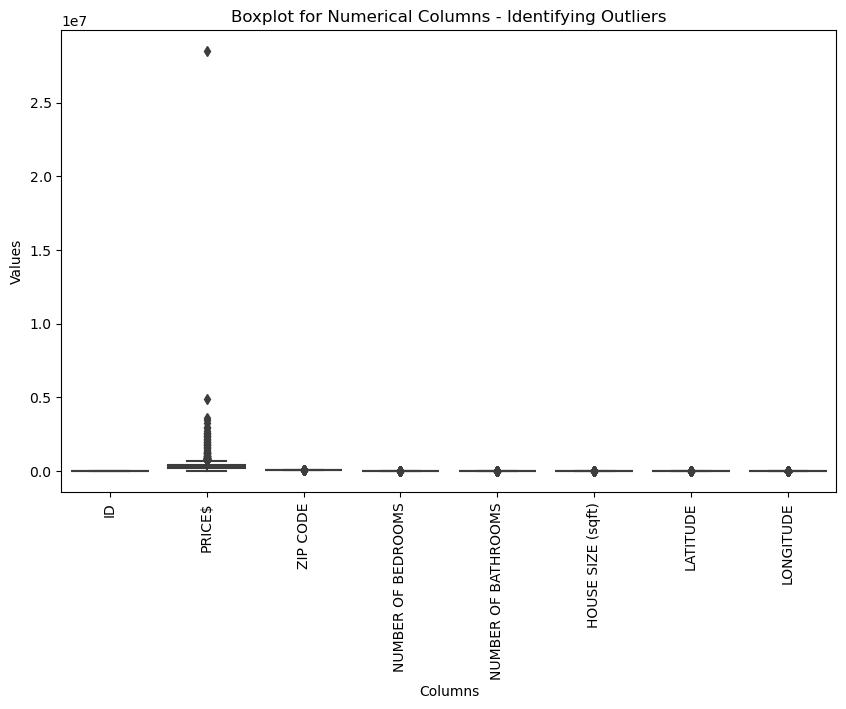

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot
plt.figure(figsize=(10, 6))

# Create boxplot for each numerical column to identify outliers
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))

# Add title and labels
plt.title('Boxplot for Numerical Columns - Identifying Outliers')
plt.xlabel('Columns')
plt.ylabel('Values')

# Display the plot
plt.xticks(rotation=90)  # Rotate column labels for better visibility
plt.show()


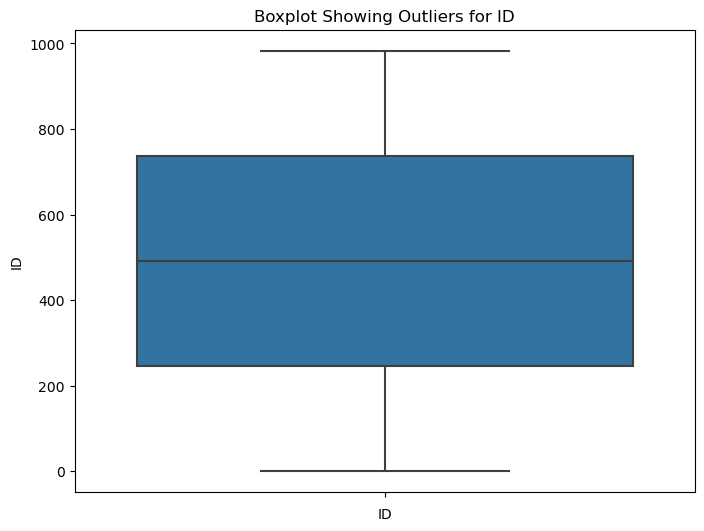

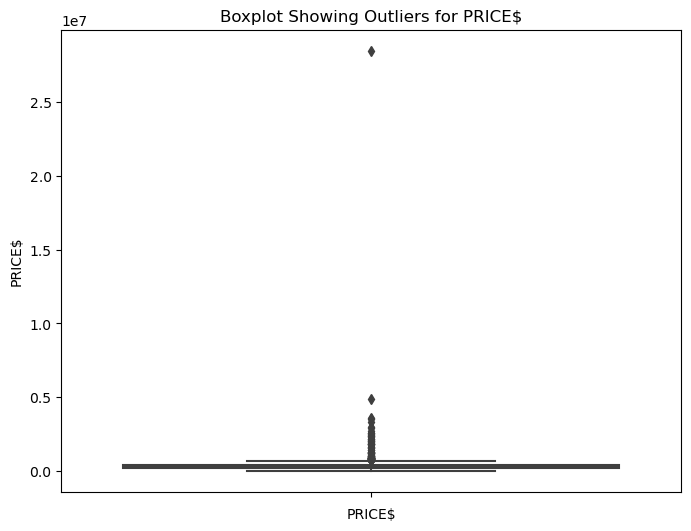

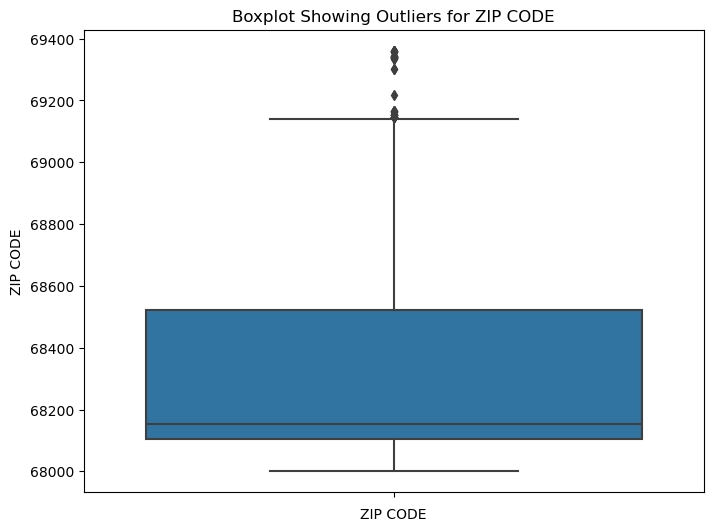

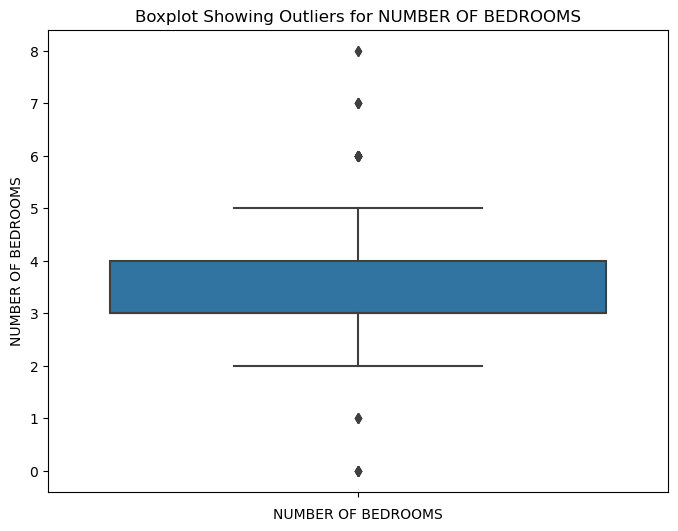

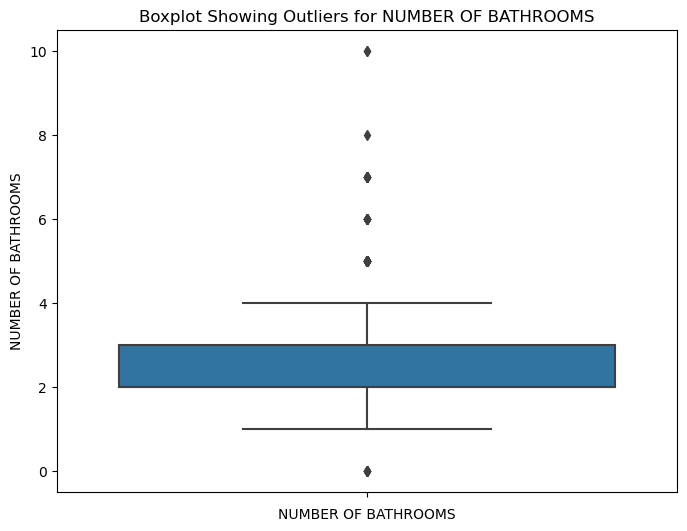

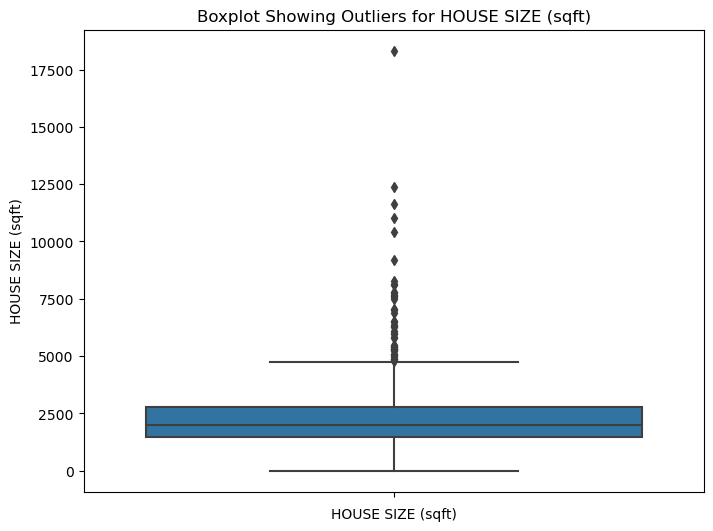

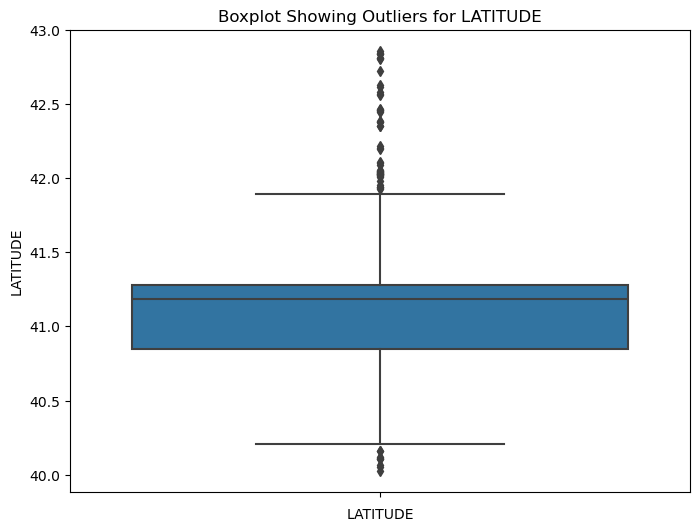

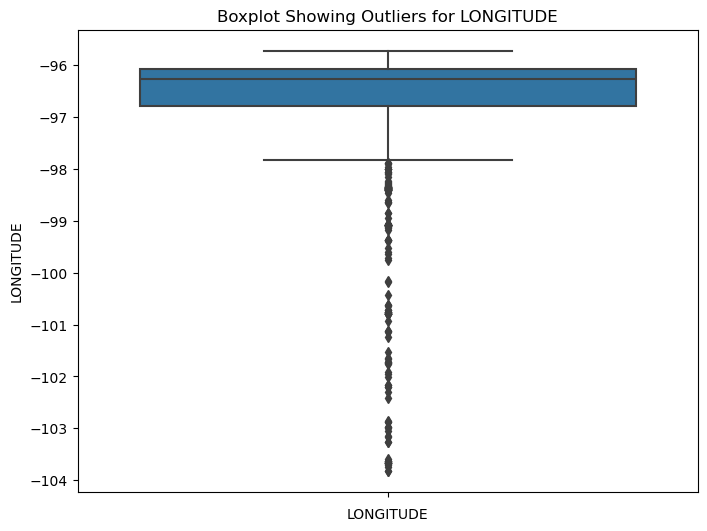

In [17]:
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(8, 6))  # Set the figure size for each plot
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot Showing Outliers for {column}')
    plt.xlabel(column)
    plt.show()

In [18]:
# Calculate IQR
Q1 = df['PRICE$'].quantile(0.25)
Q3 = df['PRICE$'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_iqr = df[(df['PRICE$'] < lower_bound) | (df['PRICE$'] > upper_bound)]

print("Outliers based on IQR:")
print(outliers_iqr)


Outliers based on IQR:
      ID     PRICE$                             FULL ADDRESS        CITY  \
1      2   997000.0      9810 Harney Pkwy N, Omaha, NE 68114       Omaha   
6      7  1795000.0       5200 Trotter Rd, Lincoln, NE 68516     Lincoln   
7      8  1450000.0  11825 N 176th Cir, Bennington, NE 68007  Bennington   
10    11  1875000.0        3105 Armbrust Dr, Omaha, NE 68124       Omaha   
14    15  1799000.0      3356 S 226th Cir, Elkhorn, NE 68022     Elkhorn   
..   ...        ...                                      ...         ...   
956  956  1300000.0        3868 S 175th Ave, Omaha, NE 68130       Omaha   
968  968  1999000.0       13650 Hamilton St, Omaha, NE 68154       Omaha   
972  972  1195000.0       7433 SW 27th St, Lincoln, NE 68523     Lincoln   
976  976  2600000.0      22509 Capehart Rd, Gretna, NE 68028      Gretna   
978  978   824900.0     11 Golfside Dr, Pleasanton, NE 68866  Pleasanton   

     ZIP CODE  NUMBER OF BEDROOMS  NUMBER OF BATHROOMS  HOUSE SI

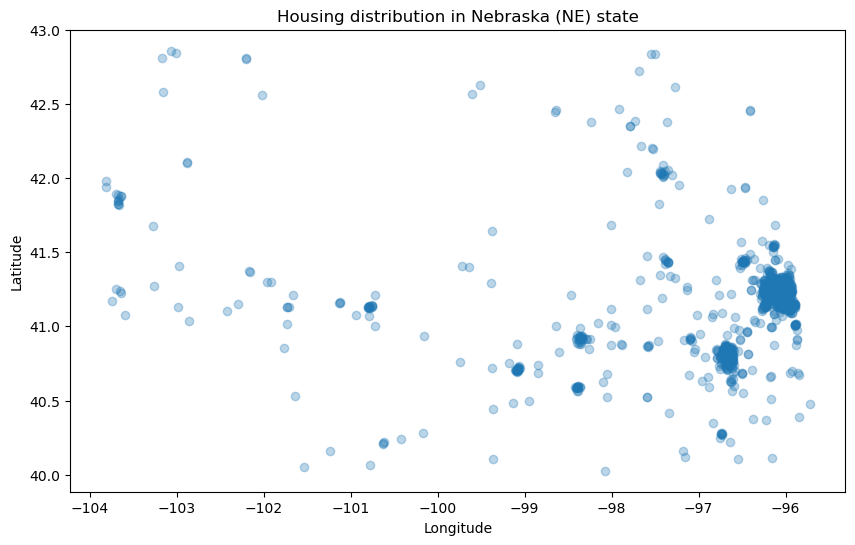

In [19]:
# Plot scatter plot of latitude and longitude
plt.figure(figsize=(10, 6))
plt.scatter(df['LONGITUDE'], df['LATITUDE'], alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Housing distribution in Nebraska (NE) state')
plt.show()

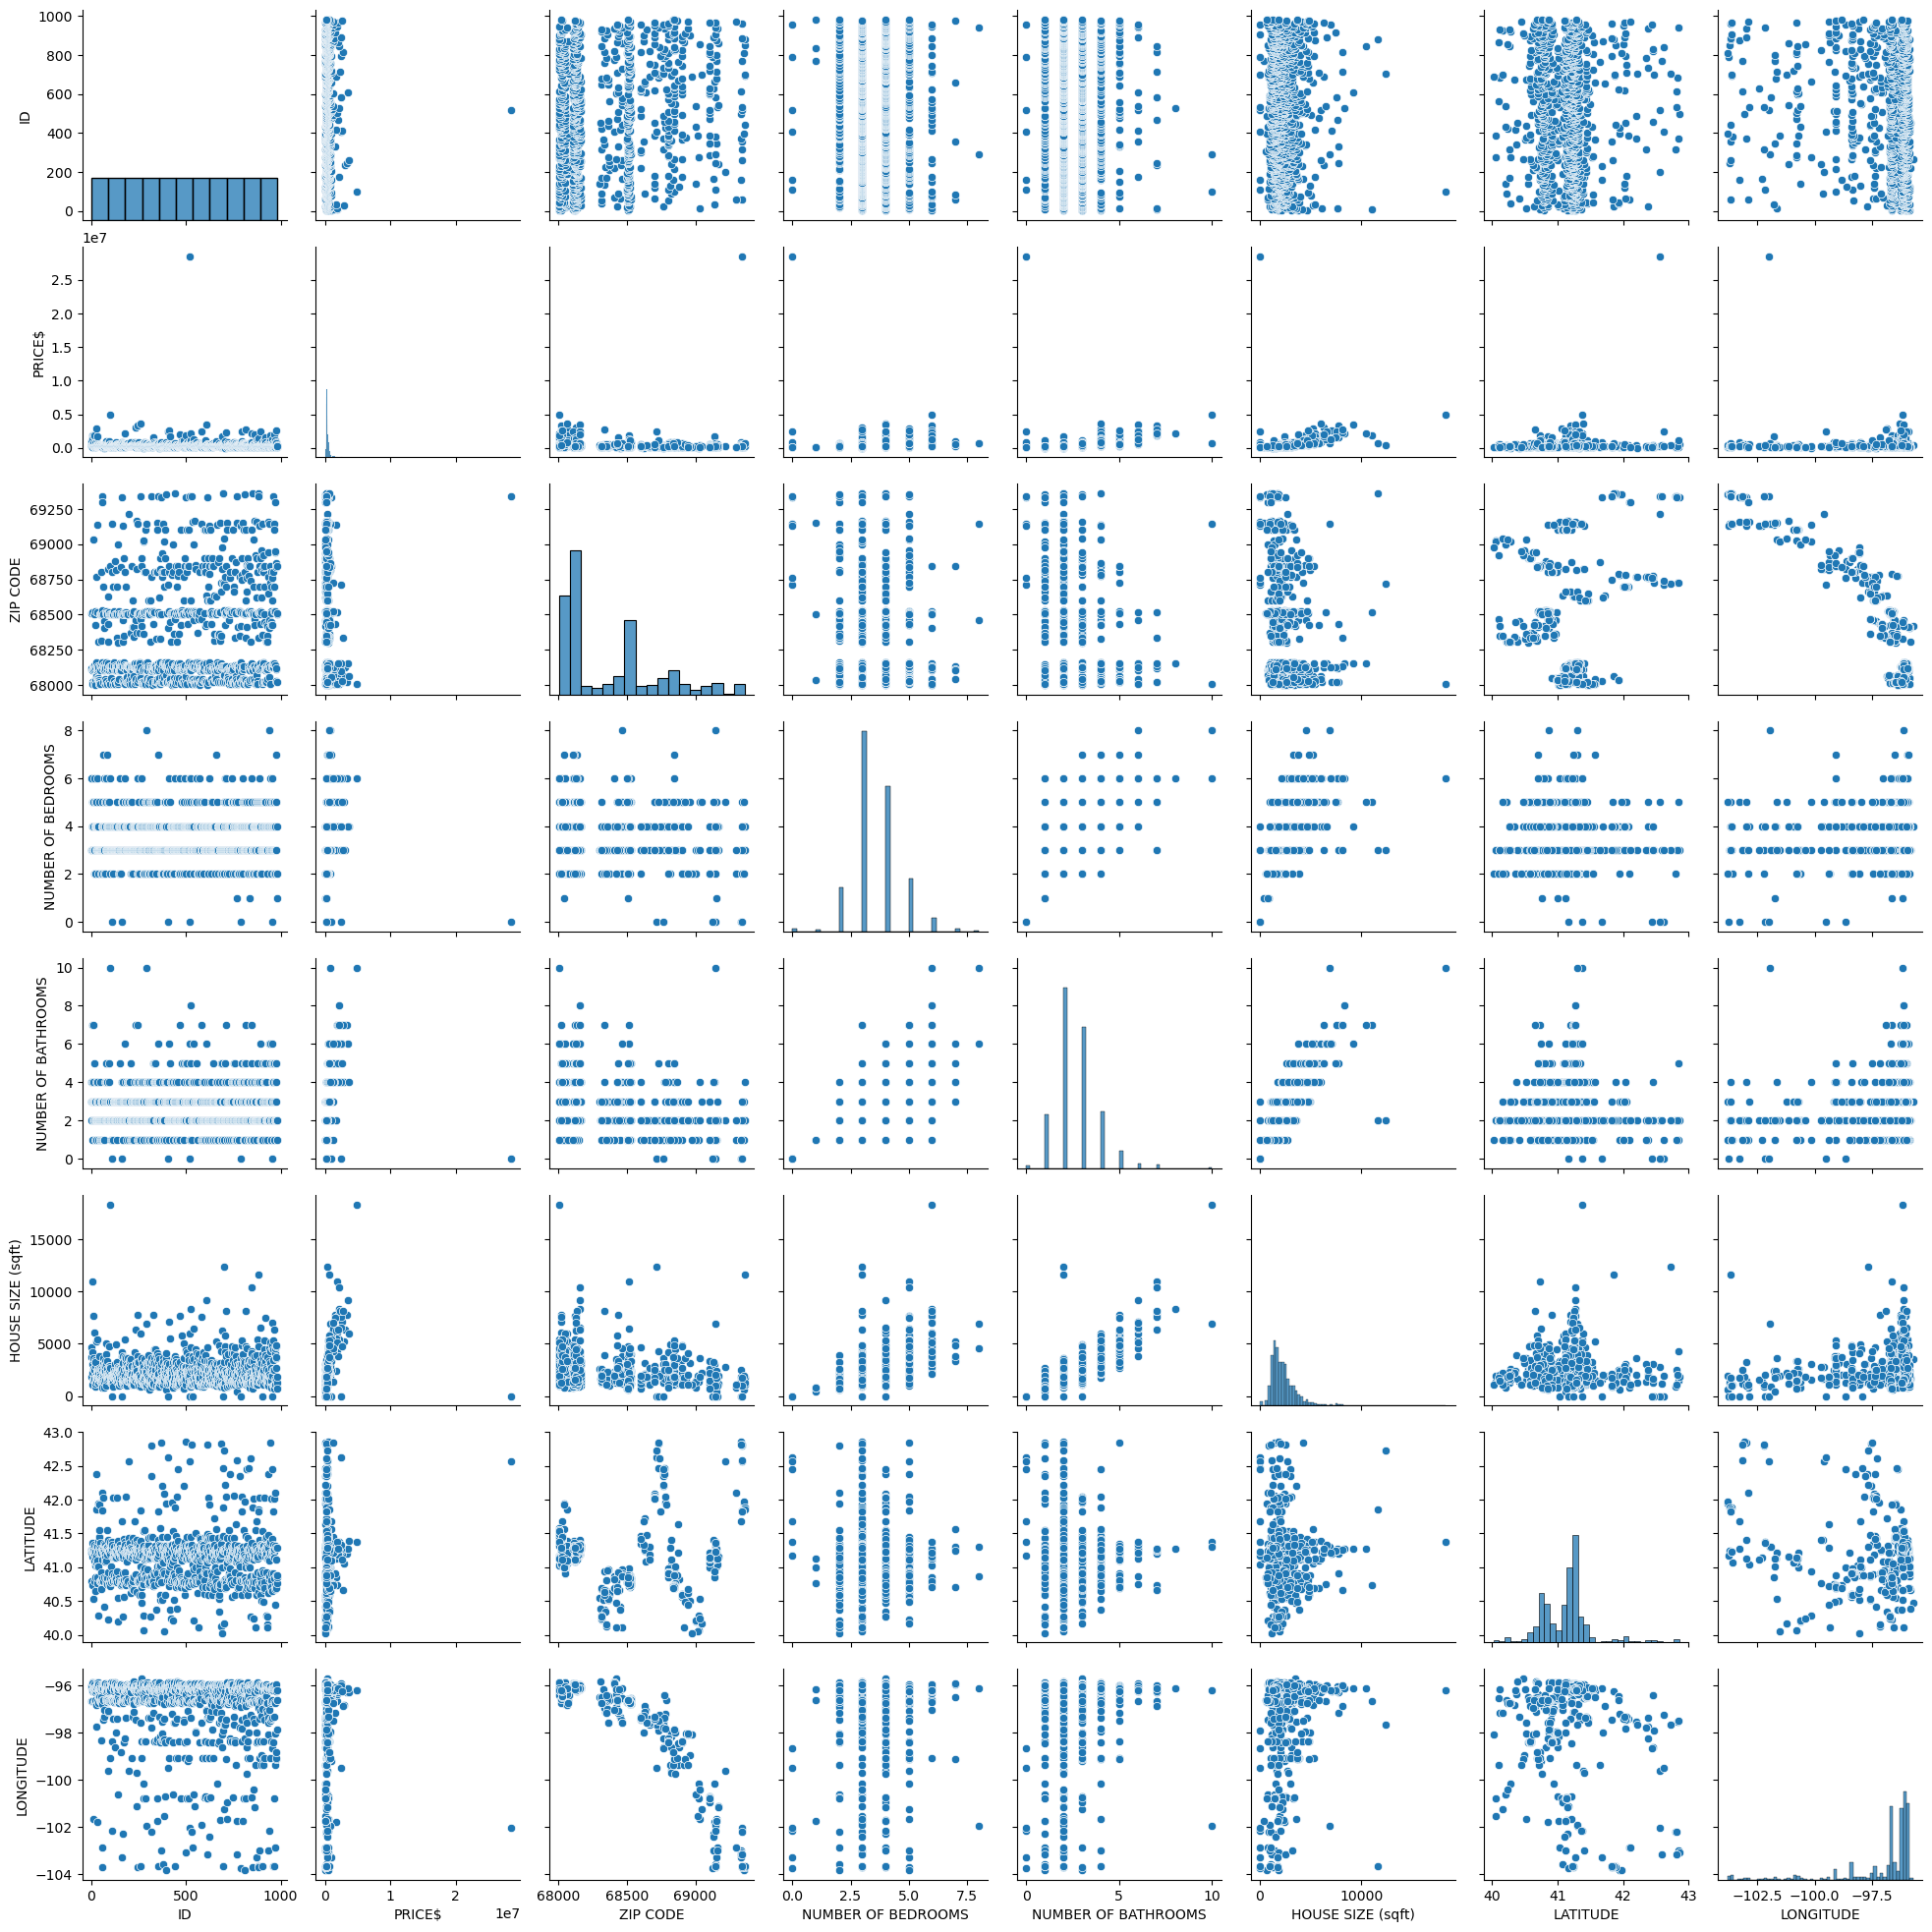

In [22]:
# Filter only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Create a pairplot for the numeric columns
sns.pairplot(numeric_df)

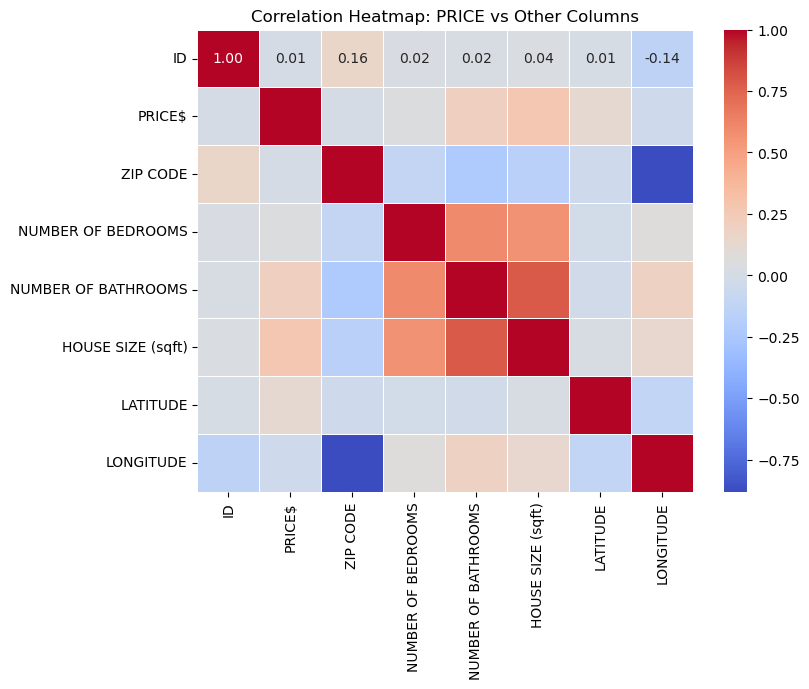

In [23]:
corr_matrix = numeric_df.corr()

# Set up the plot size
plt.figure(figsize=(8, 6))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Title and labels
plt.title('Correlation Heatmap: PRICE vs Other Columns')

# Show the plot
plt.show()

# Machine Learning

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 983 entries, 0 to 983
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   983 non-null    int64  
 1   PRICE$               983 non-null    float64
 2   FULL ADDRESS         983 non-null    object 
 3   CITY                 983 non-null    object 
 4   ZIP CODE             983 non-null    int64  
 5   NUMBER OF BEDROOMS   983 non-null    int64  
 6   NUMBER OF BATHROOMS  983 non-null    float64
 7   HOUSE SIZE (sqft)    983 non-null    float64
 8   LOT SIZE (sqft)      983 non-null    object 
 9   HOUSE TYPE           983 non-null    object 
 10  LATITUDE             983 non-null    float64
 11  LONGITUDE            983 non-null    float64
dtypes: float64(5), int64(3), object(4)
memory usage: 99.8+ KB


In [21]:
df['LOT SIZE (sqft)'] = df['LOT SIZE (sqft)'].replace(['N/A ', ''])
df['LOT SIZE (sqft)'] = pd.to_numeric(df['LOT SIZE (sqft)']).fillna(0)

In [22]:
# One-Hot Encoding for 'HOUSE TYPE'
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(df, columns=['HOUSE TYPE'], drop_first=True, dtype='int')

In [23]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
le_city = LabelEncoder()
df['CITY'] = le_city.fit_transform(df['CITY'])

In [24]:
df.describe()

,ID,PRICE$,CITY,ZIP CODE,NUMBER OF BEDROOMS,NUMBER OF BATHROOMS,HOUSE SIZE (sqft),LOT SIZE (sqft),LATITUDE,LONGITUDE,HOUSE TYPE_LOT,HOUSE TYPE_MANUFACTURED,HOUSE TYPE_MULTI FAMILY,HOUSE TYPE_SINGLE FAMILY,HOUSE TYPE_TOWNHOUSE
count,983.000000,9.830000e+02,983.000000,983.000000,983.000000,983.000000,983.000000,9.830000e+02,983.000000,983.000000,983.000000,983.000000,983.000000,983.000000,983.000000
mean,492.000000,4.377619e+05,76.880977,68363.610376,3.540183,2.643947,2360.571719,1.846617e+06,41.135115,-96.992646,0.008138,0.013225,0.007121,0.942014,0.021363
std,283.911958,9.885387e+05,30.452913,353.423423,1.019246,1.192894,1453.026201,4.379332e+07,0.397032,1.663781,0.089891,0.114294,0.084128,0.233835,0.144665
min,1.000000,1.500000e+04,0.000000,68002.000000,0.000000,0.000000,0.000000,0.000000e+00,40.026768,-103.816986,0.000000,0.000000,0.000000,0.000000,0.000000
25%,246.500000,2.290000e+05,59.000000,68106.000000,3.000000,2.000000,1474.500000,6.993000e+03,40.846339,-96.790225,0.000000,0.000000,0.000000,1.000000,0.000000
50%,492.000000,2.999000e+05,78.000000,68152.000000,3.000000,2.000000,2005.000000,9.372000e+03,41.182716,-96.264595,0.000000,0.000000,0.000000,1.000000,0.000000
75%,737.500000,4.250000e+05,96.000000,68521.000000,4.000000,3.000000,2800.500000,1.507450e+04,41.277692,-96.069890,0.000000,0.000000,0.000000,1.000000,0.000000
max,983.000000,2.850000e+07,145.000000,69361.000000,8.000000,10.000000,18320.000000,1.320795e+09,42.858425,-95.719160,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
# for outliers
df = df[
    (df['HOUSE SIZE (sqft)'] >= 1000) & (df['HOUSE SIZE (sqft)'] <= 8000) &  # Filter for house size
    (df['NUMBER OF BEDROOMS'] <= 6) &  # Filter for bedrooms
    (df['NUMBER OF BATHROOMS'] <= 5)  # Filter for bathrooms
]
df.describe()

,ID,PRICE$,CITY,ZIP CODE,NUMBER OF BEDROOMS,NUMBER OF BATHROOMS,HOUSE SIZE (sqft),LOT SIZE (sqft),LATITUDE,LONGITUDE,HOUSE TYPE_LOT,HOUSE TYPE_MANUFACTURED,HOUSE TYPE_MULTI FAMILY,HOUSE TYPE_SINGLE FAMILY,HOUSE TYPE_TOWNHOUSE
count,911.000000,9.110000e+02,911.000000,911.000000,911.000000,911.000000,911.000000,9.110000e+02,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,489.245884,3.751007e+05,76.990121,68349.574094,3.544457,2.607025,2284.018661,4.756711e+05,41.121488,-96.892064,0.005488,0.010977,0.006586,0.946213,0.023052
std,281.895871,2.900224e+05,30.359511,337.536311,0.878278,0.968354,1008.674305,1.244956e+07,0.383968,1.476106,0.073921,0.104252,0.080932,0.225721,0.150150
min,1.000000,1.500000e+04,0.000000,68002.000000,2.000000,1.000000,1000.000000,0.000000e+00,40.026768,-103.816986,0.000000,0.000000,0.000000,0.000000,0.000000
25%,245.500000,2.300000e+05,59.500000,68106.000000,3.000000,2.000000,1524.500000,7.000000e+03,40.835425,-96.751205,0.000000,0.000000,0.000000,1.000000,0.000000
50%,488.000000,2.999000e+05,78.000000,68144.000000,3.000000,2.000000,2039.000000,9.240000e+03,41.174570,-96.251310,0.000000,0.000000,0.000000,1.000000,0.000000
75%,735.500000,4.250000e+05,96.000000,68516.500000,4.000000,3.000000,2757.500000,1.437480e+04,41.275734,-96.067708,0.000000,0.000000,0.000000,1.000000,0.000000
max,983.000000,3.595000e+06,145.000000,69361.000000,6.000000,5.000000,7788.000000,3.757050e+08,42.858425,-95.719160,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
features_names=['NUMBER OF BEDROOMS', 'NUMBER OF BATHROOMS', 'HOUSE SIZE (sqft)', 'ZIP CODE', 'LOT SIZE (sqft)',
               'CITY', 'LATITUDE' , 'LONGITUDE' ,'HOUSE TYPE_LOT' ,'HOUSE TYPE_MANUFACTURED','HOUSE TYPE_MULTI FAMILY',
               'HOUSE TYPE_SINGLE FAMILY', 'HOUSE TYPE_TOWNHOUSE']

# from sklearn.preprocessing import StandardScaler

# # Initialize the StandardScaler
# scaler = StandardScaler()

# # Fit and transform the selected features
# df[features_names] = scaler.fit_transform(df[features_names])

In [27]:
features = df[features_names]
target = df['PRICE$']

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Fit a Random Forest model
model_imp = RandomForestRegressor()
model_imp.fit(features, target)

# Get feature importances
importances = model_imp.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': features_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print(feature_importance_df)

                     Feature  Importance
2          HOUSE SIZE (sqft)    0.595143
4            LOT SIZE (sqft)    0.200995
5                       CITY    0.050090
7                  LONGITUDE    0.038952
6                   LATITUDE    0.035169
3                   ZIP CODE    0.034620
1        NUMBER OF BATHROOMS    0.026786
0         NUMBER OF BEDROOMS    0.010398
11  HOUSE TYPE_SINGLE FAMILY    0.005428
9    HOUSE TYPE_MANUFACTURED    0.001924
8             HOUSE TYPE_LOT    0.000313
12      HOUSE TYPE_TOWNHOUSE    0.000101
10   HOUSE TYPE_MULTI FAMILY    0.000080


Random Forest is an ensemble learning technique that constructs multiple decision trees during training and merges their outputs to improve predictive accuracy and control overfitting. The core idea is that by combining the predictions from many individual trees, the overall model can achieve better performance than any single tree alone

In [29]:
feature_dec=['NUMBER OF BATHROOMS', 'HOUSE SIZE (sqft)','LOT SIZE (sqft)','CITY','ZIP CODE']
X = df[feature_dec]
y = df['PRICE$']
# scaler.fit_transform(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Fit the Random Forest Regressor model
model_untuned = RandomForestRegressor(random_state=42)
model_untuned.fit(X_train, y_train)


train_score = model_untuned.score(X_train, y_train)  # R² for train set
test_score = model_untuned.score(X_test, y_test)  # R² for test set


print(f"Random Forest Regressor Train R² Score: {train_score:.2f}")
print(f"Random Forest Regressor Test R² Score: {test_score:.2f}")

# Make predictions on the test set
y_pred = model_untuned.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}")

Random Forest Regressor Train R² Score: 0.94
Random Forest Regressor Test R² Score: 0.71
MAE: 81575.77, MSE: 28726350520.09


1. Mean Absolute Error (MAE)
MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

2. Mean Squared Error (MSE)
a lower MSE indicates better model performance. 

3. R-squared (R²)
R² values range from 0 to 1. A value of 0 indicates that the model does not explain any of the variability of the data around its mean, while a value of 1 indicates that it explains all the variability

In [31]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Define the Random Forest model with hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Perform Grid Search CV
model_v2 = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=model_v2, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model after tuning
model_tuned = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)

# Evaluate the model on train and test sets
y_train_pred = model_tuned.predict(X_train)
y_test_pred = model_tuned.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Tuned Random Forest Train R²: {train_r2:.2f}")
print(f"Tuned Random Forest Test R²: {test_r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

# Cross-validation for stability
cv_scores = cross_val_score(model_tuned, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R²: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Best parameters found:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Random Forest Train R²: 0.89
Tuned Random Forest Test R²: 0.77
MAE: 76515.82
MSE: 22852427364.99
Cross-Validation R²: 0.71 ± 0.04


GridSearchCV is a technique for finding the optimal hyperparameter values from a given set of parameters in a grid. It's essentially a cross-validation technique. The model as well as the parameters must be entered. After extracting the best parameter values, predictions are made.

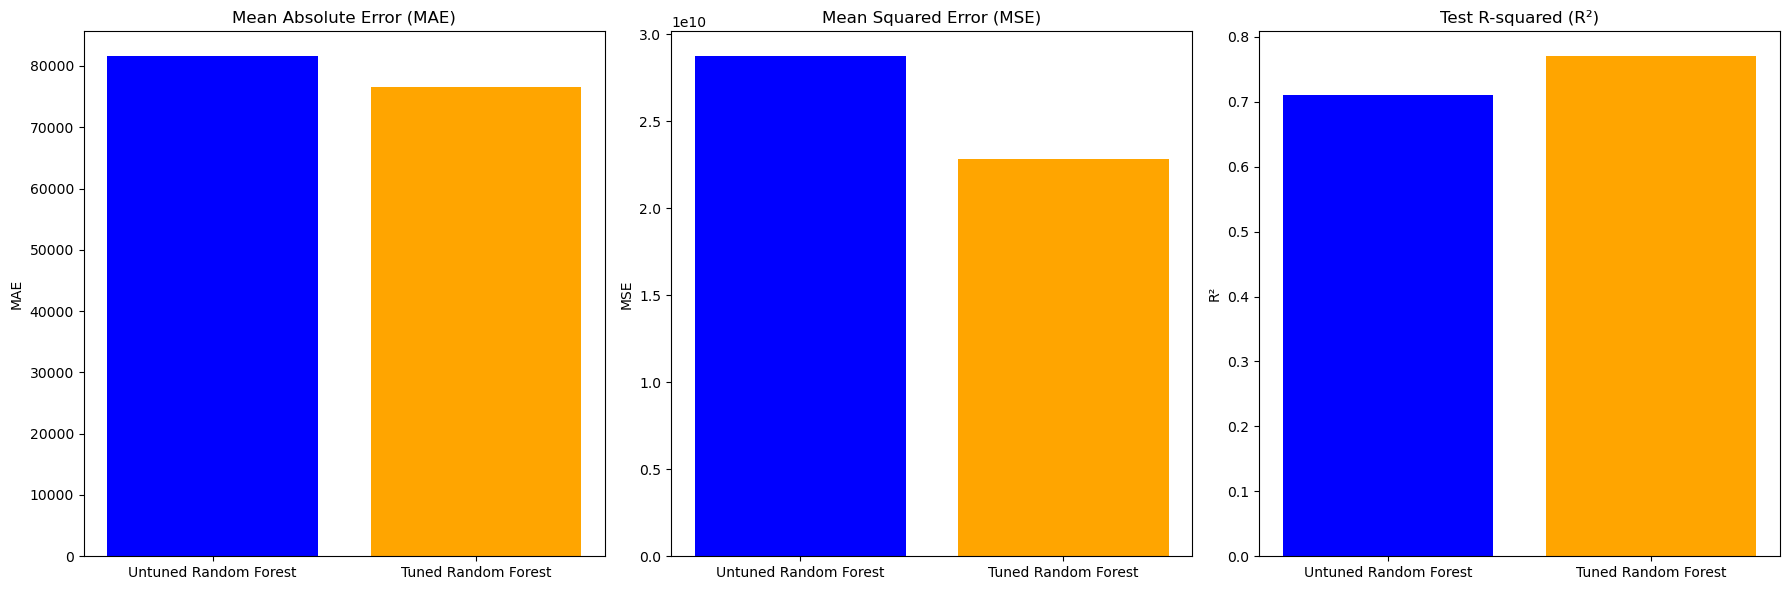

In [32]:
import matplotlib.pyplot as plt

# Metrics for Untuned and Tuned Random Forest models
mae = [81575.7681420765, 76515.82]  # Mean Absolute Error
mse = [28726350520.09235, 22852427364.99]  # Mean Squared Error
r2 = [0.71, 0.77]  # R-squared

# Labels for the models
models = ['Untuned Random Forest', 'Tuned Random Forest']

# Create a figure and axis for plotting
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plot MAE
ax[0].bar(models, mae, color=['blue', 'orange'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[0].set_ylabel('MAE')

# Plot MSE
ax[1].bar(models, mse, color=['blue', 'orange'])
ax[1].set_title('Mean Squared Error (MSE)')
ax[1].set_ylabel('MSE')

# Plot R²
ax[2].bar(models, r2, color=['blue', 'orange'])
ax[2].set_title('Test R-squared (R²)')
ax[2].set_ylabel('R²')

# Display the plot
plt.tight_layout()
plt.show()

In [33]:
def predict_price():
    print("Enter the following details to predict house price:")

    # Collect user input for each feature
    house_size = float(input("HOUSE SIZE (sqft): "))
    lot_size = float(input("LOT SIZE (sqft): "))
    number_of_bathrooms = float(input("NUMBER OF BATHROOMS: "))
    zip_code = input("ZIP CODE: ")
    city = input("CITY: ")

    # Prepare input data for prediction
    input_data = pd.DataFrame({
        'HOUSE SIZE (sqft)': [house_size],
        'LOT SIZE (sqft)': [lot_size],
        'NUMBER OF BATHROOMS': [number_of_bathrooms],
        'ZIP CODE': [zip_code],
        'CITY': [city]
    })

    # Encode the CITY feature for the input data
    if city in le_city.classes_:
        city_encoded = le_city.transform([city])[0]
    else:
        raise ValueError(f"City '{city}' not recognized. Available cities: {list(le_city.classes_)}")

    input_data['CITY'] = city_encoded

    # Make prediction
    predicted_price = model_tuned.predict(input_data[feature_dec])
    print(input_data)
    # Display predicted price
    print(f"The predicted price for the house is: ${predicted_price[0]:,.2f}")

# Call the prediction function
predict_price()

Enter the following details to predict house price:
HOUSE SIZE (sqft): 1566
LOT SIZE (sqft): 9178
NUMBER OF BATHROOMS: 1
ZIP CODE: 68506
CITY: Lincoln
   HOUSE SIZE (sqft)  LOT SIZE (sqft)  NUMBER OF BATHROOMS ZIP CODE  CITY
0             1566.0           9178.0                  1.0    68506    78
The predicted price for the house is: $222,307.25


$225,000 	1566	9178 sqft    1    68506		 Lincoln

$180,000 	768     6834 sqft    1	  68105       Omaha	

$265,000 	1560    6875 sqft    2	  68124	  Omaha	 

$320,000    1832    6534 sqft   3.0   68007    Bennington 

$269,000 	1269	7920 sqft 	 2	68801	  Grand Island

In [34]:
import joblib

# Save the model
joblib.dump(le_city,'city_label_encoder.pkl') 
joblib.dump(model_tuned, 'house_price_model_tuned.pkl')

['house_price_model_tuned.pkl']

In [35]:
# !pip install gradio

In [36]:
import pandas as pd
import gradio as gr
from sklearn.preprocessing import LabelEncoder

def predict_price(house_size, lot_size, num_bathrooms, zip_code, city):
    input_data = pd.DataFrame([{
        'HOUSE SIZE (sqft)': house_size,
        'LOT SIZE (sqft)': lot_size,
        'NUMBER OF BATHROOMS': num_bathrooms,
        'ZIP CODE': zip_code,
        'CITY': city
    }])

    # Encode the CITY feature
    if city in le_city.classes_:
        city_encoded = le_city.transform([city])[0]
    else:
        raise ValueError(f"City '{city}' not recognized. Available cities: {list(le_city.classes_)}")

    input_data['CITY'] = city_encoded

    # Ensure features align with model input
    input_data = input_data[feature_dec]

    # Make prediction
    predicted_price = model_tuned.predict(input_data)

    # Return the predicted price as a formatted string
    return f"${predicted_price[0]:,.2f}"

# Define Gradio interface inputs and outputs
inputs = [
    gr.Number(label="House Size (sqft)", value=1566),
    gr.Number(label="Lot Size (sqft)", value=9178),
    gr.Number(label="Number of Bathrooms", value=1),
    gr.Textbox(label="Zip Code", value="68506"),
    gr.Dropdown(
        choices=list(le_city.classes_),  # Convert NumPy array to list
        label="City"
    ),
]

outputs = gr.Textbox(label="Predicted Price")

# Launch the Gradio interface
gr.Interface(
    fn=predict_price,
    inputs=inputs,
    outputs=outputs,
    title="House Price Predictor"
).launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
